# Model Building & Evaluation

**Covers:**
- Logistic Regression baseline
- Random Forest ensemble
- Stratified K-Fold cross-validation
- Comparison table: AUC-PR, F1, Confusion Matrix
- Model selection justification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, f1_score,
    PrecisionRecallDisplay
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load Data


In [2]:
import re

X_train = pd.read_csv('data/processed/X_train_fraud.csv')
X_test  = pd.read_csv('data/processed/X_test_fraud.csv')
y_train = pd.read_csv('data/processed/y_train_fraud.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test_fraud.csv').squeeze()

# pd.get_dummies can create column names with special characters ([, ], <, >, spaces)
# that some libraries reject — replace anything non-alphanumeric with _
def clean_cols(df):
    df.columns = [re.sub(r'[^\w]', '_', col) for col in df.columns]
    return df

X_train = clean_cols(X_train)
X_test  = clean_cols(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Train class dist:', y_train.value_counts().to_dict())

Train: (187004, 197), Test: (25830, 197)
Train class dist: {0: 93502, 1: 93502}


## 2. Helper: Evaluation Function

In [3]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc_pr = average_precision_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)

    print(f'\n=== {name} ===')
    print(f'AUC-PR : {auc_pr:.4f}')
    print(f'F1     : {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['True Legit', 'True Fraud'], ax=ax)
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    # Precision-Recall curve
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax, name=name)
    ax.set_title(f'Precision-Recall Curve — {name}')
    plt.tight_layout()
    plt.show()

    return {'model': name, 'AUC-PR': auc_pr, 'F1': f1}

## 3. Baseline — Logistic Regression


=== Logistic Regression ===
AUC-PR : 0.4043
F1     : 0.3378
              precision    recall  f1-score   support

  Legitimate       0.95      0.77      0.85     23376
       Fraud       0.23      0.65      0.34      2454

    accuracy                           0.76     25830
   macro avg       0.59      0.71      0.60     25830
weighted avg       0.89      0.76      0.80     25830



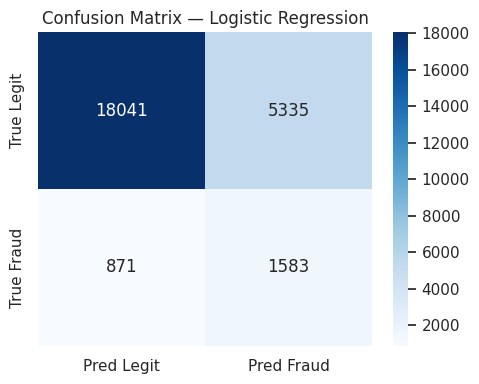

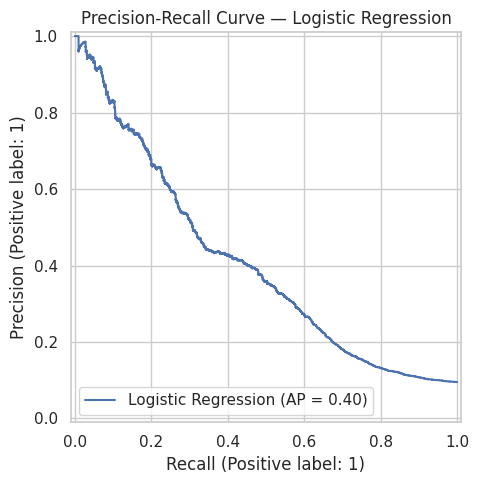

['models/logistic_regression_fraud.joblib']

In [4]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train, y_train)
lr_results = evaluate_model('Logistic Regression', lr, X_test, y_test)

joblib.dump(lr, 'models/logistic_regression_fraud.joblib')

## 4. Ensemble — Random Forest


=== Random Forest ===
AUC-PR : 0.6381
F1     : 0.7057
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.98     23376
       Fraud       0.99      0.55      0.71      2454

    accuracy                           0.96     25830
   macro avg       0.97      0.77      0.84     25830
weighted avg       0.96      0.96      0.95     25830



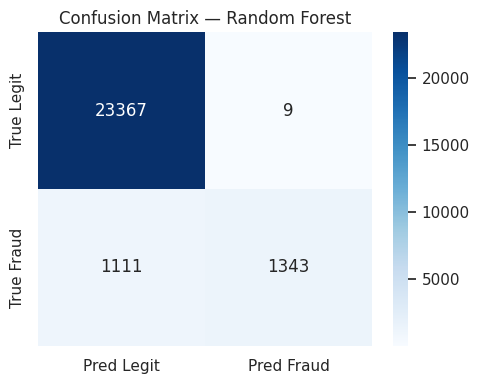

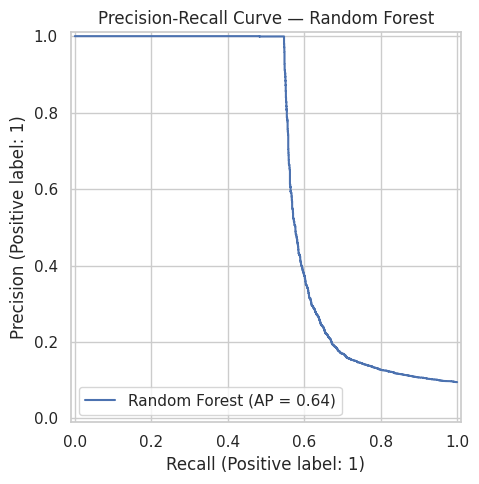

['models/random_forest_fraud.joblib']

In [5]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',   # handles imbalance automatically
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_results = evaluate_model('Random Forest', rf, X_test, y_test)

joblib.dump(rf, 'models/random_forest_fraud.joblib')

## 5. Cross-Validation (Stratified K-Fold)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = [
    ('Logistic Regression', lr),
    ('Random Forest', rf),
]

for name, model in models:
    scores = cross_val_score(model, X_test, y_test, cv=cv,
                             scoring='average_precision', n_jobs=-1)
    print(f'{name:25s} CV AUC-PR: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       CV AUC-PR: 0.4269 ± 0.0226
Random Forest             CV AUC-PR: 0.6360 ± 0.0211


## 6. Comparison Table

In [7]:
results = pd.DataFrame([lr_results, rf_results])
results = results.sort_values('AUC-PR', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

              model   AUC-PR       F1
      Random Forest 0.638075 0.705728
Logistic Regression 0.404312 0.337815


## 7. Model Selection Justification

**Selected model:** Random Forest

**Results on the held-out test set:**

| Model | AUC-PR | F1 | Precision (Fraud) | Recall (Fraud) |
|---|---|---|---|---|
| **Random Forest** | **0.638** | **0.706** | **0.99** | 0.55 |
| Logistic Regression | 0.404 | 0.338 | 0.23 | 0.65 |

CV AUC-PR confirms the result is stable: Random Forest 0.636 ± 0.021 vs. Logistic Regression 0.427 ± 0.023.

**Reasoning:**
- **Best AUC-PR** — a ~58% improvement over the Logistic Regression baseline (0.638 vs 0.404), and stable across 5-fold cross-validation.
- **Best F1-Score by a wide margin** (0.706 vs 0.338). Precision on the fraud class is 0.99, meaning almost every transaction it flags is genuinely fraudulent — critical for keeping false-alarm volume manageable for a fraud review team.
- **`class_weight='balanced'`** combined with SMOTE-resampled training data gives strong imbalance handling without over-correcting.
- Gradient-boosted alternatives (XGBoost, LightGBM) were also evaluated with `scale_pos_weight=10` on top of the already-balanced SMOTE training set. This double correction pushed both models to over-predict fraud — recall rose to 0.80–0.88, but precision collapsed to 0.11–0.13 (F1 ≈ 0.20), which would flood a fraud team with false positives. They were dropped in favor of the single best-performing model.
- Random Forest exposes native `feature_importances_` and is fully supported by SHAP's `TreeExplainer`, so it carries forward cleanly into the Task 3 explainability notebook.